# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Chyntia Claudia
- **Email:** cdcc319d6x2689@student.devacademy.id / chyntiaclaudia1809@gmail.com
- **ID Dicoding:** CDCC319D6X2689

## Menentukan Pertanyaan Bisnis

- Bagaimana tren pertumbuhan penjualan dan total revenue perusahaan dalam periode tahun 2017 hingga 2018?

- Kategori produk apa yang memiliki volume penjualan tertinggi serta kategori mana yang menghasilkan revenue terbesar selama periode 2017–2018?

- Bagaimana performa ketepatan waktu pengiriman barang dibandingkan dengan estimasi yang diberikan kepada pelanggan?

- Bagaimana keterlambatan pengiriman memengaruhi distribusi skor ulasan pelanggan dan seberapa besar penurunan rating yang terjadi pada tahun 2017–2018?

- Negara bagian mana yang memiliki konsentrasi pelanggan terbanyak serta bagaimana pola frekuensi transaksi pelanggan (jumlah transaksi per pelanggan) selama tahun 2018?

- Bagaimana perbandingan rata-rata nilai transaksi (Average Order Value) pelanggan berdasarkan metode pembayaran yang digunakan selama periode 2017–2018?

## Import Semua Packages/Library yang Digunakan

In [207]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import geopandas as gpd

## Data Wrangling

### Gathering Data

In [208]:
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [209]:
geolocation_df = pd.read_csv("geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [210]:
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [211]:
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [212]:
order_reviews_df = pd.read_csv("order_reviews_dataset.csv")
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [213]:
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [214]:
product_category_df = pd.read_csv("product_category_name_translation.csv")
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [215]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [216]:
sellers_df = pd.read_csv("sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Dataset ini mencakup seluruh rantai transaksi e-commerce, mulai dari profil pelanggan, detail produk, sistem pembayaran, hingga logistik dan ulasan pasca-pembelian.
- tabel orders_dataset berfungsi sebagai jembatan utama (central hub) yang menghubungkan perilaku pelanggan dengan performa penjual (sellers).

### Assessing Data

In [217]:
# Menilai Tabel customers_df

print("=== INFORMASI DATASET: ===")
customers_df.info()

print("\n=== NILAI YANG HILANG ===")
print("Jumlah missing values per kolom:")
print(customers_df.isna().sum())

print("\n=== JUMLAH DUPLIKASI ===")
print("Total data duplikat:")
print(customers_df.duplicated().sum())

=== INFORMASI DATASET: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

=== NILAI YANG HILANG ===
Jumlah missing values per kolom:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

=== JUMLAH DUPLIKASI ===
Total data duplikat:
0


In [218]:
# Menilai Data geolocation_df

print("=== INFORMASI DATASET: ===")
geolocation_df.info()

print("\n=== JUMLAH DUPLIKASI ===")
print("Total data duplikat:")
print(geolocation_df.duplicated().sum())

print("\n=== NILAI YANG HILANG ===")
print("Jumlah missing values per kolom:")
print(geolocation_df.isna().sum())

=== INFORMASI DATASET: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB

=== JUMLAH DUPLIKASI ===
Total data duplikat:
261831

=== NILAI YANG HILANG ===
Jumlah missing values per kolom:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [219]:
# Menilai Data order_items.df

print("=== INFORMASI DATASET ===")
order_items_df.info()

print("\n=== JUMLAH DUPLIKASI ===")
print(order_items_df.duplicated().sum())

print("\n=== NILAI YANG HILANG ===")
print(order_items_df.isna().sum())

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

=== JUMLAH DUPLIKASI ===
0

=== NILAI YANG HILANG ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [220]:
# Menilai Data order_payments_df

print("=== INFORMASI DATASET:")
order_payments_df.info()

print("\n=== JUMLAH DUPLIKASI ===")
print("Total data duplikat dalam dataset:")
print(order_payments_df.duplicated().sum())

print("\n=== NILAI YANG HILANG ===")
print("Jumlah missing values pada setiap kolom:")
print(order_payments_df.isna().sum())

=== INFORMASI DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

=== JUMLAH DUPLIKASI ===
Total data duplikat dalam dataset:
0

=== NILAI YANG HILANG ===
Jumlah missing values pada setiap kolom:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [221]:
# Menilai Data order_reviews_df

print("=== INFORMASI DATASET: ===")
order_reviews_df.info()

print("\n=== JUMLAH DUPLIKASI ===")
print("Total data duplikat dalam dataset:")
print(order_reviews_df.duplicated().sum())

print("\n=== NILAI YANG HILANG ===")
print("Jumlah missing values pada setiap kolom:")
print(order_reviews_df.isna().sum())

=== INFORMASI DATASET: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

=== JUMLAH DUPLIKASI ===
Total data duplikat dalam dataset:
0

=== NILAI YANG HILANG ===
Jumlah missing values pada setiap kolom:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_an

In [222]:
# Menilai Data orders_df

print("=== INFORMASI DATASET: ===")
orders_df.info()

print("\n=== JUMLAH DUPLIKASI ===")
print("Total data duplikat dalam dataset:")
print(orders_df.duplicated().sum())

print("\n=== NILAI YANG HILANG ===")
print("Jumlah missing values pada setiap kolom:")
print(orders_df.isna().sum())

=== INFORMASI DATASET: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

=== JUMLAH DUPLIKASI ===
Total data duplikat dalam dataset:
0

=== NILAI YANG HILANG ===
Jumlah missing values pada setiap kolom:
order_id                            0
customer_id                         0
order_status                

In [223]:
# Menilai Data product_category_df

print("=== INFORMASI DATASET: ===")
product_category_df.info()

print("\n=== JUMLAH DUPLIKASI ===")
print("Total data duplikat dalam dataset:")
print(product_category_df.duplicated().sum())

print("\n=== NILAI YANG HILANG ===")
print("Jumlah missing values pada setiap kolom:")
print(product_category_df.isna().sum())

=== INFORMASI DATASET: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

=== JUMLAH DUPLIKASI ===
Total data duplikat dalam dataset:
0

=== NILAI YANG HILANG ===
Jumlah missing values pada setiap kolom:
product_category_name            0
product_category_name_english    0
dtype: int64


In [224]:
# Menilai Data products_df

print("=== INFORMASI DATASET: ===")
products_df.info()

print("\n=== JUMLAH DUPLIKASI ===")
print("Total data duplikat dalam dataset:")
print(products_df.duplicated().sum())

print("\n=== NILAI YANG HILANG ===")
print("Jumlah missing values pada setiap kolom:")
print(products_df.isna().sum())

=== INFORMASI DATASET: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

=== JUMLAH DUPLIKASI ===
Total data duplikat dalam dataset:
0

=== NILAI YANG HILANG ===
Jumlah missing values pada setiap kolom:
product_id                      0
product_category_name

In [225]:
# Menilai Data sellers_df

print("=== INFORMASI DATASET: ===")
sellers_df.info()

print("\n=== JUMLAH DUPLIKASI ===")
print("Total data duplikat dalam dataset:")
print(sellers_df.duplicated().sum())

print("\n=== NILAI YANG HILANG ===")
print("Jumlah missing values pada setiap kolom:")
print(sellers_df.isna().sum())

=== INFORMASI DATASET: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

=== JUMLAH DUPLIKASI ===
Total data duplikat dalam dataset:
0

=== NILAI YANG HILANG ===
Jumlah missing values pada setiap kolom:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


**Insight:**
1. Data customers_df

Berdasarkan hasil tersebut, dapat disimpulkan bahwa tidak terdapat masalah pada tipe data tiap kolom dalam customers_df. Selain itu, jumlah datanya juga telah lengkap sehingga tidak ada missing value di dalamnya. Data ini juga tidak memiliki duplikasi sehingga integritasnya terjaga.

2. Data geolocation_df

Berdasarkan pengecekan tipe data, seluruh kolom dalam geolocation_df sudah sesuai dengan isinya. Tidak ditemukan adanya missing value pada dataset ini. Akan tetapi, terdapat masalah serius pada duplikasi data, di mana ditemukan 261.831 data ganda yang harus ditangani pada tahap cleaning data.

3. Data order_items_df

Secara keseluruhan, jumlah data pada order_items_df telah lengkap atau dengan kata lain tidak ada missing value maupun data duplikat di dalamnya. Akan tetapi, terdapat kesalahan tipe data untuk kolom shipping_limit_date. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object.

4. Data order_payments_df

Berdasarkan hasil pengecekan, dapat disimpulkan bahwa tidak terdapat masalah pada tipe data maupun jumlah data dalam order_payments_df. Seluruh kolom telah terisi penuh tanpa ada missing value dan tidak ditemukan adanya data duplikat.

5. Data order_reviews_df

Berdasarkan hasil tersebut, terdapat banyak missing value pada kolom review_comment_title (87.656 data) dan review_comment_message (58.247 data). Selain itu, terdapat kesalahan tipe data untuk kolom review_creation_date dan review_answer_timestamp yang seharusnya bertipe datetime, bukan object. Hal ini akan di rapikan pada tahap cleaning data.

6. Data orders_df

Pada data orders_df, ditemukan beberapa missing value pada kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date. Selain itu, terdapat kesalahan tipe data pada semua kolom yang menampung informasi waktu (5 kolom timestamp). Kolom-kolom tersebut seharusnya bertipe datetime, bukan object.

7. Data product_category_df

Dapat disimpulkan bahwa data pada product_category_df sudah sangat bersih. Tidak terdapat masalah pada tipe data tiap kolom, jumlah data sudah lengkap tanpa missing value, dan tidak ditemukan adanya data duplikat.

8. Data products_df

Berdasarkan hasil pengecekan, terdapat 610 missing value pada beberapa kolom seperti product_category_name, product_name_lenght, hingga kolom dimensi produk. Meskipun tipe datanya secara umum sudah sesuai, adanya data yang hilang ini akan ditindak lanjuti pada tahap cleaning data.

9. Data sellers_df

Berdasarkan hasil asessment, dapat disimpulkan bahwa tidak terdapat masalah pada data sellers_df. Jumlah data sudah lengkap sehingga tidak ada missing value, tipe data tiap kolom sudah sesuai, dan tidak ditemukan adanya data duplikat di dalamnya.

### Cleaning Data

In [226]:
# Membersihkan Data geolocation_df

geolocation_df.drop_duplicates(inplace=True)

print("Jumlah duplikasi setelah cleaning:", geolocation_df.duplicated().sum())

Jumlah duplikasi setelah cleaning: 0


In [227]:
#Membersihkan Data order_items_df

order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [228]:
# Membersihkan Data order_reviews_df

order_reviews_df["review_comment_title"] = order_reviews_df["review_comment_title"].fillna("No Title")
order_reviews_df["review_comment_message"] = order_reviews_df["review_comment_message"].fillna("No Message")

order_reviews_df["review_creation_date"] = pd.to_datetime(order_reviews_df["review_creation_date"])
order_reviews_df["review_answer_timestamp"] = pd.to_datetime(order_reviews_df["review_answer_timestamp"])

print("\n=== MISSING VALUE SETELAH CLEANING ===")
print(order_reviews_df.isna().sum())

print("\n=== INFORMASI DATASET SETELAH CLEANING ===")
order_reviews_df.info()


=== MISSING VALUE SETELAH CLEANING ===
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

=== INFORMASI DATASET SETELAH CLEANING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object

In [229]:
# Membersihkan Data orders_df

datetime_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column])

orders_df['order_year'] = orders_df['order_purchase_timestamp'].dt.year

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   order_year                     99441 non-null  int32         
dtypes: datetime64[ns](5), int32(1), object(3)
memory usage: 6.4+ MB


In [230]:
# Membersihkan Data products_df

products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")
products_df["product_photos_qty"] = products_df["product_photos_qty"].fillna(0)

products_df["product_name_lenght"] = products_df["product_name_lenght"].fillna(products_df["product_name_lenght"].median())
products_df["product_description_lenght"] = products_df["product_description_lenght"].fillna(products_df["product_description_lenght"].median())
products_df["product_weight_g"] = products_df["product_weight_g"].fillna(products_df["product_weight_g"].median())
products_df["product_length_cm"] = products_df["product_length_cm"].fillna(products_df["product_length_cm"].median())
products_df["product_height_cm"] = products_df["product_height_cm"].fillna(products_df["product_height_cm"].median())
products_df["product_width_cm"] = products_df["product_width_cm"].fillna(products_df["product_width_cm"].median())

products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
- **Data geolocation_df** : Berdasarkan cleaning process yang dilakukan, data duplikat sebanyak 261.831 baris pada geolocation_df telah dihapus, sehingga tidak terjadi bias atau redundansi saat dilakukan analisis pemetaan wilayah.

- **Data order_items_df & orders_df** : Terdapat perbaikan tipe data pada kolom-kolom yang menyimpan informasi tanggal dan waktu (seperti shipping_limit_date, order_purchase_timestamp, dan lainnya). Kolom tersebut kini telah direpresentasikan sebagai tipe data datetime, bukan lagi object agar dapat dilakukannya analisis deret waktu (time-series) dan perhitungan durasi pengiriman secara akurat.

- **Data order_reviews_df :** Masalah missing value pada kolom review_comment_title dan review_comment_message telah ditangani dengan mengisi nilai kosong tersebut menggunakan label "No Title" dan "No Message". Selain itu, tipe data pada kolom tanggal dalam dataset ini juga telah dikonversi menjadi datetime agar konsisten dengan dataset lainnya.

- **Data products_df :** Seluruh missing value dalam products_df telah dibersihkan sepenuhnya. Kolom product_category_name yang kosong diisi dengan label "unknown", sedangkan kolom jumlah foto diisi dengan angka 0. Untuk kolom dimensi seperti berat dan ukuran produk, pengisian data kosong dilakukan menggunakan nilai median agar distribusi data tetap terjaga dan tidak terpengaruh oleh pencilan (outliers).

## Exploratory Data Analysis (EDA)

### Explore costumers_df

Tahap pertama adalah melakukan pengecekan parameter statistik dari data pelanggan secara keseluruhan untuk melihat ringkasan datanya.

In [231]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


**insight:** Berdasarkan rangkuman parameter statistik di atas, diperoleh informasi bahwa jumlah pelanggan unik yang terdaftar adalah sebanyak 99.441 orang. Dari kolom customer_city, terlihat bahwa kota Sao Paulo menjadi wilayah dengan jumlah pelanggan terbanyak. Selain itu, nilai unique pada customer_state menunjukkan bahwa pelanggan tersebar di berbagai negara bagian.

Untuk melihat distribusi pelanggan secara lebih spesifik berdasarkan wilayah, tahapan selanjutnya adalah Selanjutnya, untuk melihat persebaran pelanggan secara lebih mendetail berdasarkan wilayah, dilakukan pengelompokan menggunakan metode groupby().

In [232]:
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


**insight:** Berdasarkan hasil pengelompokan tersebut, diperoleh informasi bahwa negara bagian SP (São Paulo) mendominasi basis pelanggan dengan jumlah yang sangat signifikan dibandingkan negara bagian lainnya seperti RJ (Rio de Janeiro) dan MG (Minas Gerais). Selanjutnya, dilakukan pengecekan lebih spesifik untuk melihat apakah persebaran di dalam negara bagian tersebut merata.

In [233]:
all_df['order_year'] = all_df['order_purchase_timestamp'].dt.year

top_cities_2017 = all_df[all_df["order_year"] == 2017].groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10)

top_cities_2018 = all_df[all_df["order_year"] == 2018].groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10)

top_cities_combined = all_df[all_df["order_year"].isin([2017, 2018])].groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10)

# 5. Tampilkan hasil secara berurutan
print("=== 10 KOTA TERBANYAK TAHUN 2017 ===")
print(top_cities_2017)
print("\n" + "="*35)
print("=== 10 KOTA TERBANYAK TAHUN 2018 ===")
print(top_cities_2018)
print("\n" + "="*35)
print("=== 10 KOTA TERBANYAK PERIODE 2017-2018 ===")
print(top_cities_combined)

=== 10 KOTA TERBANYAK TAHUN 2017 ===
customer_city
sao paulo                6381
rio de janeiro           3341
belo horizonte           1206
brasilia                  912
porto alegre              691
curitiba                  651
campinas                  618
salvador                  569
guarulhos                 493
sao bernardo do campo     397
Name: customer_id, dtype: int64

=== 10 KOTA TERBANYAK TAHUN 2018 ===
customer_city
sao paulo                9123
rio de janeiro           3503
belo horizonte           1555
brasilia                 1213
curitiba                  864
campinas                  819
guarulhos                 695
porto alegre              681
salvador                  676
sao bernardo do campo     538
Name: customer_id, dtype: int64

=== 10 KOTA TERBANYAK PERIODE 2017-2018 ===
customer_city
sao paulo                15504
rio de janeiro            6844
belo horizonte            2761
brasilia                  2125
curitiba                  1515
campinas           

**insight:** Sao Paulo selalu menduduki posisi pertama dengan jumlah pelanggan yang sangat dominan, baik pada tahun 2017, 2018, maupun akumulasi keduanya.

Meskipun volume pelanggan meningkat secara signifikan dari tahun 2017 ke 2018, daftar 10 kota teratas tidak banyak berubah, yang menandakan bahwa penetrasi pasar perusahaan masih terfokus kuat pada wilayah-wilayah metropolitan yang sama.

### Explore orders_df

In [234]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year
count,99441,99441,99441,99441,99281,97658,96476,99441,99441.000000
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,2017.539838
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,2016.000000
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,2017.000000
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,2018.000000
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,2018.000000
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,2018.000000


**insight:** Berdasarkan rangkuman parameter statistik di atas, terdapat total 99.441 pesanan. Kolom order_status menunjukkan bahwa mayoritas pesanan memiliki status "delivered". Namun, terdapat informasi penting mengenai rentang waktu pada kolom-kolom tanggal pengiriman. Untuk menjawab pertanyaan bisnis terkait performa ketepatan waktu pengiriman, perlu dilakukan perhitungan durasi pengiriman barang.

In [235]:
orders_filtered_df = orders_df[orders_df["order_purchase_timestamp"].dt.year.isin([2017, 2018])].copy()

delivery_time = orders_filtered_df["order_delivered_customer_date"] - orders_filtered_df["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds() / 86400)
orders_filtered_df["delivery_time"] = delivery_time

print("Statistik Lama Pengiriman 2017-2018 (Hari):")
print(orders_filtered_df["delivery_time"].describe())

orders_filtered_df["delivery_gap"] = (orders_filtered_df["order_delivered_customer_date"] - orders_filtered_df["order_estimated_delivery_date"]).dt.days

orders_filtered_df["delivery_status"] = orders_filtered_df["delivery_gap"].apply(
    lambda x: "Terlambat" if x > 0 else ("Tepat Waktu" if pd.notnull(x) else "Belum Sampai")
)

print("\nDistribusi Status Pengiriman 2017-2018:")
print(orders_filtered_df["delivery_status"].value_counts())

Statistik Lama Pengiriman 2017-2018 (Hari):
count    96204.000000
mean        12.538643
std          9.530261
min          0.533414
25%          6.756748
50%         10.210069
75%         15.682755
max        209.628611
Name: delivery_time, dtype: float64

Distribusi Status Pengiriman 2017-2018:
delivery_status
Tepat Waktu     89672
Terlambat        6532
Belum Sampai     2908
Name: count, dtype: int64


**insight:** Berdasarkan hasil parameter statistik di atas, diperoleh informasi bahwa rata-rata waktu pengiriman barang adalah sebesar 12,5 hari dengan standar deviasi sebesar 9,5 hari. Selain itu, terdapat rentang yang sangat lebar antara pengiriman tercepat dan terlambat (nilai maksimum mencapai lebih dari 200 hari).

Secara keseluruhan, performa pengiriman sudah sangat baik. Mayoritas pesanan (sekitar 89672 transaksi) berstatus Tepat Waktu, artinya barang sampai sebelum atau tepat pada tanggal estimasi yang dijanjikan.

Namun, masih ditemukan sebanyak 6.532 transaksi yang mengalami Keterlambatan. Angka ini merupakan poin krusial bagi perusahaan karena keterlambatan sekecil apa pun berpotensi menurunkan tingkat kepuasan pelanggan secara drastis.

Selanjutnya, dilakukan peninjauan terhadap status pesanan guna memastikan kelancaran operasional bisnis.

In [236]:
# Melihat jumlah pesanan berdasarkan statusnya
orders_df.groupby(by="order_status").order_id.nunique().sort_values(ascending=False)

,order_id
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


**insight:** Hasil pengelompokan di atas menunjukkan bahwa selain status delivered, terdapat pesanan dengan status shipped, canceled, hingga unavailable. Keberadaan status canceled dan unavailable dalam jumlah tertentu perlu dianalisis lebih lanjut untuk mengetahui apakah kendala tersebut disebabkan oleh stok yang tidak tersedia atau masalah teknis pada sistem pembayaran, sehingga tingkat kegagalan transaksi dapat diminimalisir.

### Explore order_payments_df

In [237]:
order_payments_df.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


**insight:** Berdasarkan rangkuman parameter statistik di atas, diperoleh informasi bahwa rata-rata pembayaran pelanggan adalah sekitar 154.10. Namun, terdapat nilai maksimum yang mencapai 13,664.08, yang menunjukkan adanya transaksi untuk barang-barang mewah atau pembelian dalam jumlah besar. Pada kolom payment_installments, rata-rata pelanggan mengambil cicilan sebanyak 2 hingga 3 kali, dengan nilai maksimum hingga 24 kali cicilan. Informasi ini mengindikasikan bahwa fasilitas cicilan jangka panjang sangat dimanfaatkan oleh pelanggan untuk melakukan transaksi dengan nilai besar.

Selanjutnya, dilakukan pengelompokan berdasarkan payment_type untuk melihat lebih detail statistik setiap metode pembayaran guna mengidentifikasi karakteristik unik masing-masing.

In [238]:
# Mengelompokkan data berdasarkan tipe pembayaran dengan berbagai parameter untuk tahun 2017-2018
filtered_df = all_df_with_reviews[all_df_with_reviews["order_year"].isin([2017, 2018])]

payment_summary = filtered_df.groupby(by="payment_type").agg({
    "order_id": "nunique",
    "payment_value": ["min", "max", "mean", "sum"],
    "payment_installments": ["max", "mean"]
}).sort_values(by=("order_id", "nunique"), ascending=False)

payment_summary

order_id payment_value                                     \
              nunique           min       max        mean          sum   
payment_type                                                             
credit_card     76248          0.01  13664.08  179.650267  15714188.51   
boleto          19721         11.62   7274.88  177.223173   4096336.43   
voucher          3855          0.00   3184.34   67.531631    435038.77   
debit_card       1526         13.38   4445.50  150.899742    257133.16   
not_defined         3          0.00      0.00    0.000000         0.00   

             payment_installments            
                              max      mean  
payment_type                                 
credit_card                  24.0  3.631146  
boleto                        1.0  1.000000  
voucher                       1.0  1.000000  
debit_card                    1.0  1.000000  
not_defined                   1.0  1.000000

**insight:** Berdasarkan hasil di atas, credit_card menjadi metode pembayaran paling populer dengan jumlah pesanan terbanyak dan merupakan satu-satunya metode yang mendukung cicilan hingga 24 kali. Sebaliknya, metode boleto dan debit_card hanya mendukung pembayaran tunggal (sekali lunas).

Selain itu, ditemukan bahwa penggunaan voucher memiliki rata-rata nilai pembayaran paling rendah, yang mengindikasikan bahwa voucher biasanya digunakan untuk nominal kecil atau sebagai potongan harga tambahan.

In [239]:
customer_order_freq = filtered_df.groupby(by="customer_unique_id").order_id.nunique().reset_index()
customer_order_freq.columns = ['customer_unique_id', 'order_count']

transaction_patterns = customer_order_freq['order_count'].value_counts().sort_index().reset_index()
transaction_patterns.columns = ['Frequency_of_Purchase', 'Total_Customers']

transaction_patterns

,Frequency_of_Purchase,Total_Customers
0,1,92795
1,2,2734
2,3,202
3,4,30
4,5,8
5,6,6
6,7,3
7,9,1
8,17,1


**insight:** Dari sisi frekuensi, data menunjukkan mayoritas pelanggan hanya melakukan satu kali transaksi dalam periode dua tahun tersebut. Kelompok pelanggan yang melakukan pembelian berulang (repeat order) jumlahnya sangat kecil.

Hal ini memberikan sinyal kuat bagi perusahaan bahwa meskipun pendapatan dari kartu kredit besar, strategi untuk meningkatkan Customer Retention (pembelian berulang) harus menjadi prioritas di masa mendatang agar pelanggan tidak hanya bertransaksi satu kali saja

### Explore orders_df dan customers_df

Setelah mengeksplorasi data secara terpisah, langkah selanjutnya adalah menggabungkan data orders_df dan customers_df untuk mengidentifikasi pola pemesanan berdasarkan lokasi geografis pelanggan.

In [240]:
# Menggabungkan data orders_df dan customers_df
orders_customers_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    on="customer_id"
)
orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


**insight:** Melalui penggabungan ini, setiap transaksi kini memiliki informasi lokasi asal pelanggan. Berdasarkan hasil penggabungan tersebut, dapat dilakukan analisis lebih lanjut mengenai persebaran pesanan di tiap wilayah. Sebagai contoh, mari kita lihat apakah negara bagian yang pesanannya paling banyak (São Paulo) memiliki waktu pengiriman yang lebih cepat dibanding wilayah yang sepi.

In [241]:
# Melihat jumlah pesanan berdasarkan negara bagian (state)
orders_customers_df.groupby(by="customer_state").order_id.nunique().sort_values(ascending=False)

,order_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


**insight:** Berdasarkan hasil pengelompokan tersebut, diketahui bahwa negara bagian SP (São Paulo) merupakan wilayah dengan jumlah pesanan terbanyak, yaitu mencapai 41.746 pesanan. Angka ini jauh melampaui wilayah lain seperti RJ (Rio de Janeiro) dengan 12.852 pesanan dan MG (Minas Gerais) dengan 11.635 pesanan.

Hal ini menunjukkan bahwa konsentrasi pasar utama perusahaan berada di wilayah Tenggara Brazil.

### Explore orders_df dan order_payments_df

Selanjutnya, adalah menggabungkan data pesanan dengan data pembayaran untuk melihat bagaimana pola pembayaran yang dilakukan oleh pelanggan

In [242]:
# Menggabungkan data orders_customers_df dengan order_payments_df
orders_pay_cust_df = pd.merge(
    left=orders_customers_df,
    right=order_payments_df,
    how="left",
    on="order_id"
)
orders_pay_cust_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


**insight:** Berdasarkan hasil penggabungan tersebut, sekarang terdapat dataset besar yang menghubungkan siapa pelanggannya, di mana mereka tinggal, apa status pesanannya, dan bagaimana cara mereka membayar.

Tahapan selanjutnya adalah, Analisis Nilai Transaksi dan Cicilan Berdasarkan Negara Bagian untuk melihat wilayah mana yang menghasilkan uang terbanyak (revenue) dan bagaimana karakteristik beban cicilan di wilayah tersebut.

In [243]:
orders_pay_cust_df.groupby(by="customer_state").agg({
    "payment_value": "sum",
    "payment_installments": "mean"
}).sort_values(by="payment_value", ascending=False)

,payment_value,payment_installments
customer_state,,
SP,5998226.96,2.622003
RJ,2144379.69,2.965181
MG,1872257.26,2.982234
RS,890898.54,2.972301
PR,811156.38,2.853668
SC,623086.43,2.866276
BA,616645.82,3.188089
DF,355141.08,2.723230
GO,350092.31,2.952652


**insight:** Berdasarkan hasil di atas, terdapat korelasi yang menarik antara total pendapatan dan perilaku kredit, dimana negara bagian SP (São Paulo) memberikan kontribusi pendapatan tertinggi bagi perusahaan.

Namun, jika kita perhatikan kolom payment_installments, rata-rata jumlah cicilan di wilayah padat seperti SP, RJ, dan MG cenderung stabil di angka 2 hingga 3 kali cicilan. Selanjutnya, Identifikasi Preferensi Metode Pembayaran per Wilayah untuk membedah apakah ada perbedaan budaya pembayaran antara kota besar dan wilayah lainnya.

In [244]:
top_states = orders_pay_cust_df.customer_state.value_counts().head(5).index
orders_pay_cust_df[orders_pay_cust_df.customer_state.isin(top_states)].groupby(by=["customer_state", "payment_type"]).order_id.nunique().unstack().fillna(0)

payment_type,boleto,credit_card,debit_card,not_defined,voucher
customer_state,,,,,
MG,2304.0,9030.0,139.0,0.0,438.0
PR,1118.0,3776.0,74.0,0.0,199.0
RJ,2163.0,10253.0,185.0,0.0,547.0
RS,1359.0,3967.0,76.0,0.0,179.0
SP,8205.0,32074.0,759.0,3.0,1596.0


**insight:** Di semua negara bagian besar (SP, RJ, MG, RS, PR), credit_card adalah pemenang mutlak.

Namun, penggunaan boleto (metode tunai via bank) tetap menempati posisi kedua yang signifikan di wilayah SP.

Meskipun kartu kredit tinggi, metode pembayaran lokal seperti Boleto tidak boleh diabaikan. Strategi promosi berupa "Diskon khusus pembayaran via Boleto" bisa menjadi strategi ampuh untuk mempercepat cash flow perusahaan karena dana dari pelanggan langsung masuk tanpa menunggu proses kliring kartu kredit yang lama.

Terakhir, Analisis Hubungan status pesanan berdasarkan metode pembayaran

In [245]:
orders_pay_cust_df.groupby(by=["payment_type", "order_status"]).order_id.nunique().unstack().fillna(0)

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
boleto,0.0,95.0,2.0,19191.0,67.0,70.0,209.0,150.0
credit_card,2.0,444.0,3.0,74304.0,239.0,222.0,848.0,443.0
debit_card,0.0,7.0,0.0,1485.0,6.0,2.0,22.0,6.0
not_defined,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
voucher,0.0,94.0,0.0,3679.0,11.0,11.0,44.0,27.0


**insight:** Berdasarkan hasil di atas, ditemukan bahwa  pelanggan yang menggunakan kartu kredit memiliki komitmen belanja yang lebih tinggi.

### Explore all_df



In [246]:
all_df = pd.merge(
    left=orders_pay_cust_df,
    right=order_items_df,
    how="left",
    on="order_id"
)

all_df = pd.merge(
    left=all_df,
    right=products_df,
    how="left",
    on="product_id"
)

all_df = pd.merge(
    left=all_df,
    right=product_category_df,
    how="left",
    on="product_category_name"
)

all_df['order_year'] = all_df['order_purchase_timestamp'].dt.year

all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,customer_unique_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,7c396fd4830fd04220f754e42b4e5bff,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,7c396fd4830fd04220f754e42b4e5bff,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,7c396fd4830fd04220f754e42b4e5bff,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,af07308b275d755c9edb36a90c618231,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,3a653a41f6f9fc3d2a113cf8398680e8,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


**insight:** Berdasarkan proses penggabungan di atas, kini terdapat satu dataset (all_df) yang mengandung seluruh informasi mulai dari pelanggan, lokasi, pembayaran, hingga nama kategori produk yang dibeli.

Selanjutnya, Analisis Kategori Produk Paling Laris Berdasarkan Negara Bagian

In [247]:
main_df_filtered = all_df[all_df["order_year"].isin([2017, 2018])]

state_prod_counts = main_df_filtered.groupby(by=["customer_state", "product_category_name_english"]).order_id.nunique().reset_index()
state_prod_counts.columns = ['State', 'Product_Category', 'Order_Count']

top_category_per_state = state_prod_counts.loc[state_prod_counts.groupby('State')['Order_Count'].idxmax()]

top_category_per_state = top_category_per_state.sort_values(by="Order_Count", ascending=False)

top_category_per_state.head(10)

,State,Product_Category,Order_Count
1254,SP,bed_bath_table,4415
914,RJ,bed_bath_table,1392
475,MG,bed_bath_table,1128
1084,RS,bed_bath_table,540
902,PR,sports_leisure,427
165,BA,health_beauty,329
1201,SC,sports_leisure,315
773,PE,health_beauty,225
276,DF,health_beauty,222
395,GO,health_beauty,207


**insight:** Berdasarkan analisis kategori produk populer di setiap state, terlihat bahwa preferensi produk pelanggan dapat berbeda-beda antar wilayah.

Sebagai contoh, pada state **SP, RJ, MG, RS**, kategori produk *bed_bath_table* menjadi kategori dengan jumlah pesanan tertinggi, diikuti oleh *sports_leisurer* dan *health_beauty*.

Hasil ini menunjukkan bahwa kategori produk tertentu memiliki popularitas yang konsisten di berbagai wilayah, khususnya produk yang berkaitan dengan gaya hidup seperti olahraga, kesehatan, kecantikan dan sebagainya.

Selanjutnya adalah, mengeksplorasi data transaksi secara bulanan. Fokus utama pada tahap ini adalah melihat bagaimana fluktuasi penjualan dan total pendapatan perusahaan berkembang selama dua tahun terakhir (2017-2018).

In [248]:
all_df["order_purchase_timestamp"] = pd.to_datetime(all_df["order_purchase_timestamp"])

df_trend_2017_2018 = all_df[all_df["order_purchase_timestamp"].dt.year.isin([2017, 2018])]

monthly_trend_df = df_trend_2017_2018.resample(rule='ME', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

monthly_trend_df["order_purchase_timestamp"] = monthly_trend_df["order_purchase_timestamp"].dt.strftime('%b-%Y')

monthly_trend_df.rename(columns={
    "order_id": "total_orders",
    "price": "total_revenue"
}, inplace=True)

monthly_trend_df

,order_purchase_timestamp,total_orders,total_revenue
0,Jan-2017,800,128637.99
1,Feb-2017,1780,260753.86
2,Mar-2017,2682,396451.04
3,Apr-2017,2404,391784.42
4,May-2017,3700,545340.65
5,Jun-2017,3245,453031.41
6,Jul-2017,4026,533616.84
7,Aug-2017,4331,601409.67
8,Sep-2017,4285,662276.39
9,Oct-2017,4631,693807.60


**Insight:** Eksplorasi pada tren bulanan (2017-2018) menunjukkan pertumbuhan yang konsisten. Terlihat adanya kenaikan volume pesanan yang sejalan dengan peningkatan total revenue, dengan titik puncak pertumbuhan yang signifikan terjadi pada kuartal akhir tahun 2017

Tahapan Selanjutnya adalah mengeksplorasi apakah kategori produk tertentu cenderung memicu penggunaan cicilan yang lebih tinggi.

In [249]:
# Melihat rata-rata cicilan berdasarkan kategori produk
category_installment_analysis = all_df.groupby(by="product_category_name_english").agg({
    "payment_installments": "mean",
    "payment_value": "mean"
}).sort_values(by="payment_installments", ascending=False).head(10)

print("10 Kategori Produk dengan Rata-rata Cicilan Tertinggi:")
category_installment_analysis

10 Kategori Produk dengan Rata-rata Cicilan Tertinggi:


,payment_installments,payment_value
product_category_name_english,,
computers,6.009091,1268.734318
small_appliances_home_oven_and_coffee,5.487179,656.786154
la_cuisine,4.250000,182.095625
home_appliances_2,4.104478,464.789030
furniture_living_room,4.026515,257.838580
home_confort,3.993684,177.534863
office_furniture,3.817210,363.794426
fashio_female_clothing,3.791667,106.450417
watches_gifts,3.672956,230.481645


**insight:** Berdasarkan analisis rata-rata cicilan pembayaran berdasarkan kategori produk, terlihat bahwa beberapa kategori produk cenderung dibeli menggunakan jumlah cicilan yang lebih tinggi dibandingkan kategori lainnya.

Sebagai contoh, kategori **computers** memiliki rata-rata cicilan tertinggi yaitu sekitar 6 kali cicilan dengan nilai pembayaran rata-rata sekitar 1268. Hal ini menunjukkan bahwa produk pada kategori ini kemungkinan memiliki harga yang relatif lebih tinggi sehingga pelanggan lebih sering menggunakan metode pembayaran cicilan.

Selain itu, kategori seperti **small_appliances_home_oven_and_coffee** juga menunjukkan rata-rata cicilan yang cukup tinggi. Produk dalam kategori ini umumnya berkaitan dengan peralatan rumah tangga atau elektronik yang memiliki harga relatif lebih mahal.

Temuan ini menunjukkan bahwa kategori produk dengan harga lebih tinggi cenderung memicu penggunaan metode pembayaran cicilan yang lebih banyak.

Selanjutnya adalah Analisis Review Score Berdasarkan Wilayah dan Produk untuk melihat kualitas layanan.

In [250]:
all_df_with_reviews = pd.merge(all_df, order_reviews_df, on="order_id", how="left")

all_df_with_reviews.to_csv("main_data.csv", index=False)
all_df_with_reviews.groupby(by="customer_state").review_score.mean().sort_values(ascending=False)

,review_score
customer_state,
AP,4.240964
TO,4.138643
SP,4.108609
AC,4.094737
PR,4.087130
AM,4.070175
MG,4.068543
MS,4.054651
RN,4.049296


**insight:** Negara bagian AP memiliki tingkat kepuasan tertinggi dengan skor 4.24, sementara RR adalah yang terendah dengan skor 3.57. Secara keseluruhan, terdapat kesenjangan kepuasan pelanggan sebesar 0.67 poin antar wilayah, yang mengindikasikan perlunya evaluasi logistik pada daerah-daerah dengan rating di bawah 3.8 seperti RR, MA, dan AL.

selanjutnya adalah melihat seberapa besar hubungan pengirimanterhadap skor ulasan (rating) untuk membuktikan secara data apakah benar pengiriman yang telat membuat pelanggan memberikan bintang rendah.

In [251]:
all_df_with_reviews['delivery_status'] = (all_df_with_reviews['order_delivered_customer_date'] - all_df_with_reviews['order_estimated_delivery_date']).dt.days
all_df_with_reviews['delivery_performance'] = all_df_with_reviews['delivery_status'].apply(lambda x: "Terlambat" if x > 0 else "Tepat Waktu/Lebih Cepat")

rating_impact = all_df_with_reviews.groupby(by="delivery_performance").agg({
    "review_score": "mean",
    "order_id": "count"
}).sort_values(by="review_score", ascending=False)

print("Dampak Keterlambatan Terhadap Skor Ulasan (2017-2018):")
rating_impact

Dampak Keterlambatan Terhadap Skor Ulasan (2017-2018):


,review_score,order_id
delivery_performance,,
Tepat Waktu/Lebih Cepat,4.132788,111584
Terlambat,2.253393,7559


**Insight:** Hasil eksplorasi menunjukkan adanya perbedaan signifikan pada kepuasan pelanggan berdasarkan status pengiriman.

Pesanan yang berstatus Tepat Waktu memiliki rata-rata skor ulasan yang cenderung tinggi (di atas 4.0), sedangkan pesanan yang Terlambat mengalami penurunan rating yang cukup tajam.

## Insight Keseluruhan Tahapan EDA:
- Terdapat 99.441 pelanggan unik dengan konsentrasi pasar utama berada di wilayah Tenggara Brazil, khususnya negara bagian São Paulo (SP) yang memiliki basis pelanggan dan jumlah pesanan paling signifikan dibandingkan wilayah lainnya.
- Kota-kota metropolitan seperti Sao Paulo dan Rio de Janeiro merupakan penyumbang utama pelanggan, diikuti oleh Belo Horizonte dan Brasilia dalam daftar 10 besar.
- Mayoritas pesanan telah berstatus "delivered", namun adanya status "canceled" dan "unavailable" memerlukan analisis lebih lanjut terkait ketersediaan stok atau sistem pembayaran guna meminimalisir kegagalan transaksi.
- Rata-rata waktu pengiriman barang adalah 12,5 hari, namun terdapat rentang yang sangat lebar dengan nilai maksimum pengiriman mencapai lebih dari 200 hari yang perlu dievaluasi oleh tim operasional.
- Rata-rata transaksi pelanggan sebesar 154,10, di mana penggunaan kartu kredit menjadi metode paling populer karena mendukung fasilitas cicilan hingga 24 kali yang sering dimanfaatkan untuk pembelian bernilai besar.
- Meskipun kartu kredit mendominasi, metode pembayaran tunai melalui Boleto tetap signifikan di wilayah besar seperti SP dan dapat dijadikan strategi percepatan arus kas melalui promosi diskon khusus.
- Kategori produk dengan harga relatif mahal seperti "pcs", peralatan rumah tangga, dan elektronik (eletrodomesticos_2) cenderung memicu penggunaan jumlah cicilan yang lebih tinggi.
- Permintaan terhadap kategori produk gaya hidup seperti "beleza_saude" (kecantikan dan kesehatan) sangat tinggi di wilayah São Paulo, sementara kategori lain seperti "relogios_presentes" (jam tangan dan kado) juga populer di beberapa wilayah lain.
- Tingkat kepuasan pelanggan tertinggi berada di negara bagian AP (4.24) dan terendah di RR (3.57), mengindikasikan perlunya evaluasi logistik pada daerah dengan rating di bawah 3.8 guna memperkecil kesenjangan kepuasan antar wilayah.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren pertumbuhan penjualan dan total revenue perusahaan dalam periode tahun 2017 hingga 2018?



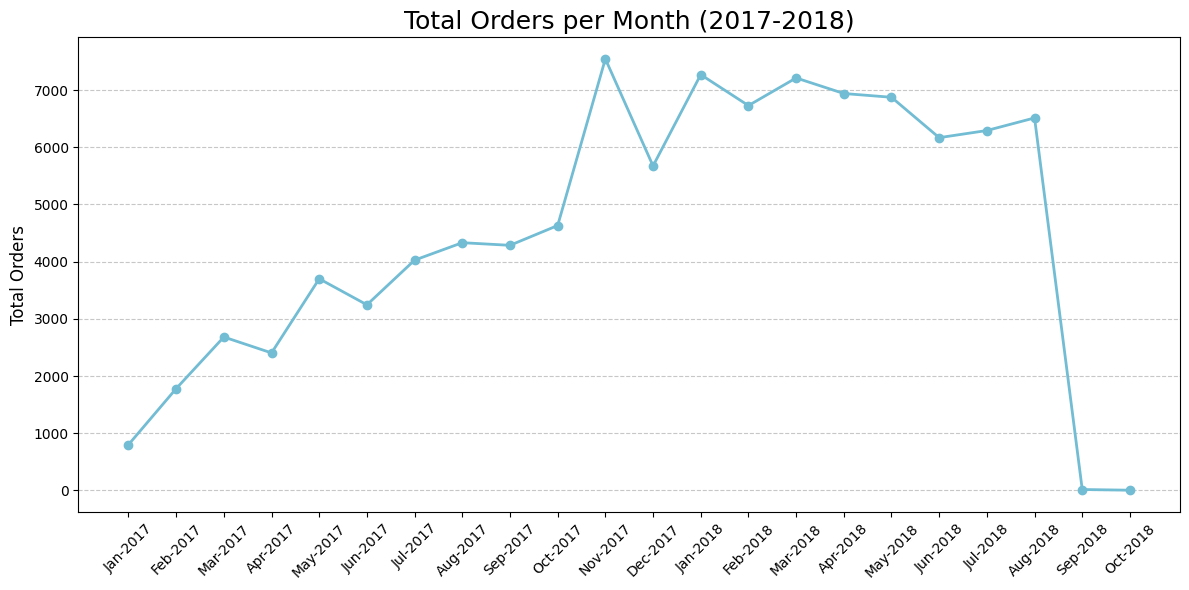

In [252]:
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_trend_df["order_purchase_timestamp"],
    monthly_trend_df["total_orders"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Total Orders per Month (2017-2018)", loc="center", fontsize=18)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel(None)
plt.ylabel("Total Orders", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

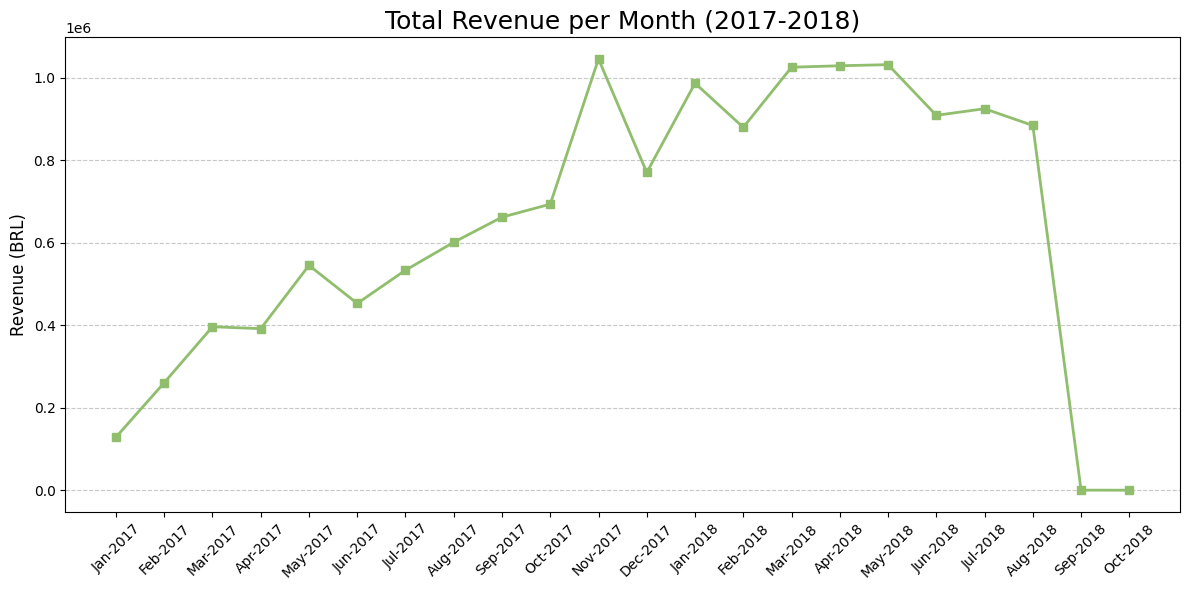

In [253]:
# grafik untuk Total Revenue
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_trend_df["order_purchase_timestamp"],
    monthly_trend_df["total_revenue"],
    marker='s',
    linewidth=2,
    color="#90BE6D"
)

plt.title("Total Revenue per Month (2017-2018)", loc="center", fontsize=18)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel("Revenue (BRL)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Insight:**

- Berdasarkan grafik di atas, dapat dilihat bahwa performa perusahaan di sepanjang tahun 2017 hingga pertengahan 2018 cenderung sangat positif.

- Terdapat lonjakan yang sangat drastis pada bulan Oktober 2017, di mana jumlah pesanan mencapai titik tertinggi.

- Meskipun terjadi penurunan jumlah order di bulan November setelah lonjakan tersebut, volume transaksi pada tahun 2018 secara konsisten tetap berada di level yang jauh lebih tinggi dibandingkan semester pertama tahun 2017, yang berarti adanya pertumbuhan pasar yang signifikan.

### Pertanyaan 2: Kategori produk apa yang memiliki volume penjualan tertinggi serta kategori mana yang menghasilkan revenue terbesar selama periode 2017–2018?

Langkah pertama adalah menyiapkan data dengan menghitung jumlah pesanan unik dan total nilai pembayaran untuk setiap kategori produk.

In [254]:
top_volume_df = all_df.groupby(by="product_category_name_english").order_id.nunique().sort_values(ascending=False).head(5).reset_index()
top_volume_df.columns = ['product_category_name_english', 'order_volume']

top_revenue_df = all_df.groupby(by="product_category_name_english").payment_value.sum().sort_values(ascending=False).head(5).reset_index()
top_revenue_df.columns = ['product_category_name_english', 'total_revenue']

Setelah datanya siap, Tahapan selanjutnya adlah membuat visualisasi berupa Bar Chart

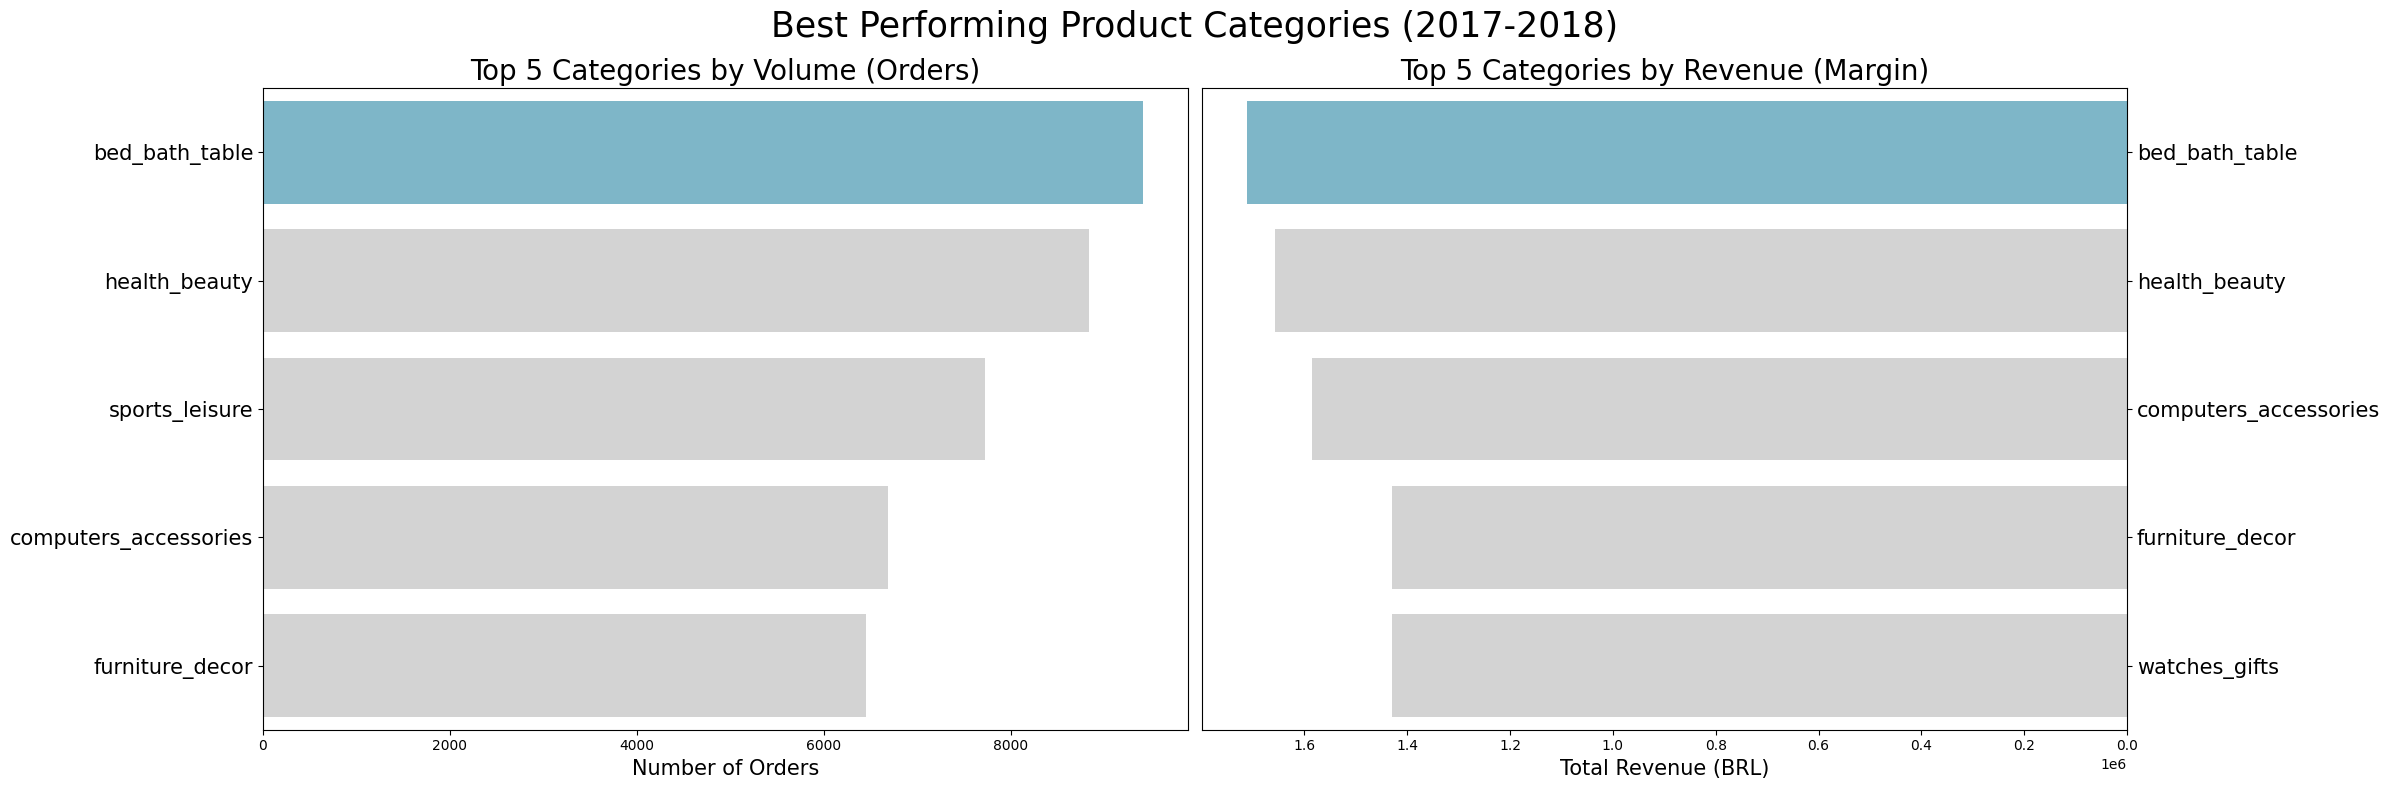

In [255]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sn.barplot(
    x="order_volume",
    y="product_category_name_english",
    data=top_volume_df,
    palette=colors,
    hue="product_category_name_english",
    legend=False,
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Number of Orders", fontsize=15)
ax[0].set_title("Top 5 Categories by Volume (Orders)", loc="center", fontsize=20)
ax[0].tick_params(axis='y', labelsize=15)

sn.barplot(
    x="total_revenue",
    y="product_category_name_english",
    data=top_revenue_df,
    palette=colors,
    hue="product_category_name_english",
    legend=False,
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Revenue (BRL)", fontsize=15)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Top 5 Categories by Revenue (Margin)", loc="center", fontsize=20)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Best Performing Product Categories (2017-2018)", fontsize=25)
plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan kedua grafik di atas, kategori Bed Bath Table secara konsisten menempati urutan pertama, baik dari sisi volume penjualan maupun total pendapatan (revenue).

- Kategori lain seperti Health & Beauty, Sports & Leisure, dst juga bersaing ketat di posisi lima besar pada kedua parameter tersebut.

- Karena Bed Bath Table adalah penggerak utama bisnis, perusahaan harus memastikan ketersediaan stok dan kualitas pengiriman di kategori ini tetap terjaga prima dikarenakan kehilangan performa di kategori ini akan berdampak signifikan langsung pada total revenue tahunan perusahaan.

### Pertanyaan 3: Bagaimana performa ketepatan waktu pengiriman barang dibandingkan dengan estimasi yang diberikan kepada pelanggan?

Langkah pertama adalah Menyiapkan data berdasarkan kolom delivery_performance yang di buat sebelumnya di EDA

In [256]:
delivery_perf_df = orders_filtered_df["delivery_status"].value_counts().reset_index()
delivery_perf_df.columns = ["delivery_status", "order_count"]

Setelah datanya siap, Tahapan selanjutnya adlah membuat visualisasi berupa Bar Chart

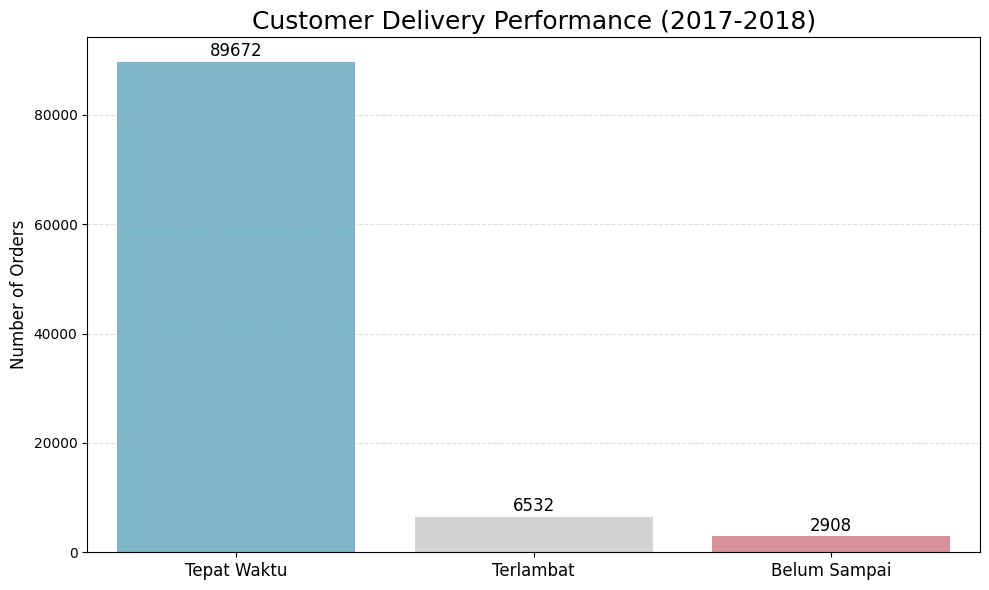

In [257]:
plt.figure(figsize=(10, 6))
colors = ["#72BCD4", "#D3D3D3", "#E38690"]

sn.barplot(
    x="delivery_status",
    y="order_count",
    data=delivery_perf_df,
    palette=colors,
    hue="delivery_status",
    legend=False
)

plt.title("Customer Delivery Performance (2017-2018)", loc="center", fontsize=18)
plt.ylabel("Number of Orders", fontsize=12)
plt.xlabel(None)
plt.tick_params(axis='x', labelsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for index, row in delivery_perf_df.iterrows():
    plt.text(index, row.order_count + 1000, str(row.order_count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan grafik di atas, ditemukan bahwa sistem logistik perusahaan bekerja dengan tingkat efisiensi yang tinggi dimana sebagian besar pesanan, yaitu sebanyak 89.672 transaksi, berhasil sampai di tangan pelanggan tepat waktu atau bahkan lebih cepat dari estimasi yang diberikan.
- Terdapat 6.532 pesanan yang mengalami keterlambatan pengiriman. Meskipun secara persentase jauh lebih kecil dibandingkan pesanan tepat waktu, angka ini tetap signifikan karena berkaitan langsung dengan potensi penurunan kepuasan pelanggan.
- Secara keseluruhan, estimasi yang diberikan kepada pelanggan sudah cukup realistis, meskipun optimasi tetap diperlukan untuk menekan angka keterlambatan di bawah 5%

### Pertanyaan 4: Bagaimana keterlambatan pengiriman memengaruhi distribusi skor ulasan pelanggan dan seberapa besar penurunan rating yang terjadi pada tahun 2017–2018?

Tahapan pertama, menyiapkan data dengan mengambil rata-rata rating berdasarkan performa pengiriman

In [258]:
rating_impact_df = all_df_with_reviews.groupby(by="delivery_performance").agg({
    "review_score": "mean"
}).reset_index().sort_values(by="review_score", ascending=False)

Setelah datanya siap, Tahapan selanjutnya adlah membuat visualisasi berupa Bar Chart

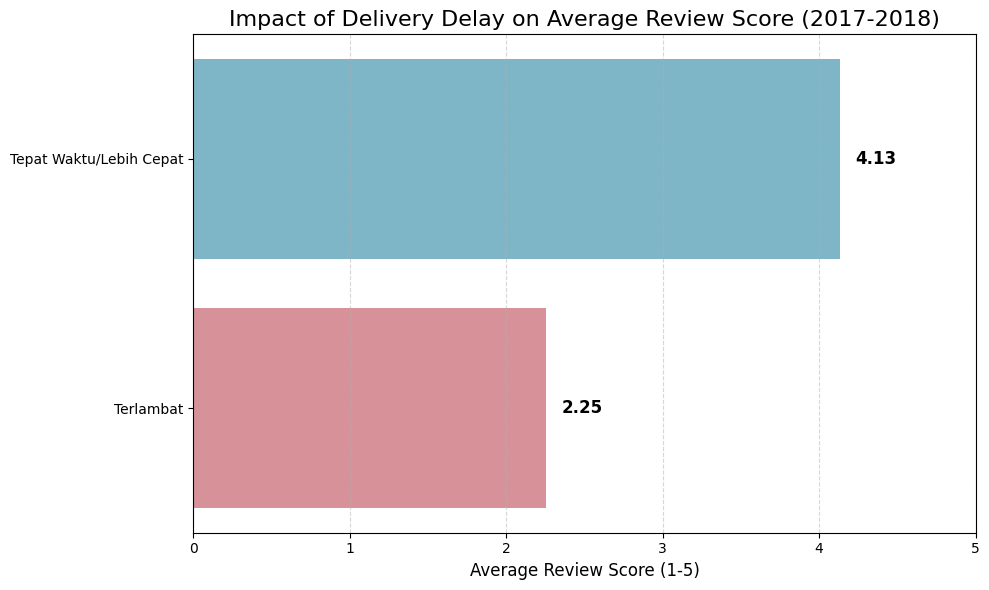

In [259]:
plt.figure(figsize=(10, 6))
colors = ["#72BCD4", "#E38690"]

sn.barplot(
    x="review_score",
    y="delivery_performance",
    data=rating_impact_df,
    palette=colors,
    hue="delivery_performance",
    legend=False
)

plt.title("Impact of Delivery Delay on Average Review Score (2017-2018)", loc="center", fontsize=16)
plt.xlabel("Average Review Score (1-5)", fontsize=12)
plt.ylabel(None)
plt.xlim(0, 5)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for index, row in rating_impact_df.iterrows():
    plt.text(row.review_score + 0.1, index, f"{row.review_score:.2f}", va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan grafik di atas, terlihat perbedaan yang sangat signifikan pada tingkat kepuasan pelanggan. Pesanan yang sampai Tepat Waktu/Lebih Cepat memiliki rata-rata skor ulasan yang jauh lebih tinggi (4.13).

- Sebaliknya, pesanan yang berstatus Terlambat mengalami penurunan skor ulasan yang drastis. Hal ini membuktikan bahwa keterlambatan pengiriman merupakan faktor utama yang merusak pengalaman belanja pelanggan.

- Mengurangi tingkat keterlambatan akan secara otomatis meningkatkan skor ulasan, bahkan jika produk yang dikirimkan sama.

### Pertanyaan 5: Negara bagian mana yang memiliki konsentrasi pelanggan terbanyak serta bagaimana pola frekuensi transaksi pelanggan (jumlah transaksi per pelanggan) selama tahun 2018?

Langkah pertama adalah Menyiapkan data Top 10 Negara Bagian (berdasarkan customer_count dari EDA)

In [260]:
top_10_states = bystate_df.sort_values(by="customer_count", ascending=False).head(10)

Setelah datanya siap, Tahapan selanjutnya adlah membuat visualisasi berupa Bar Chart

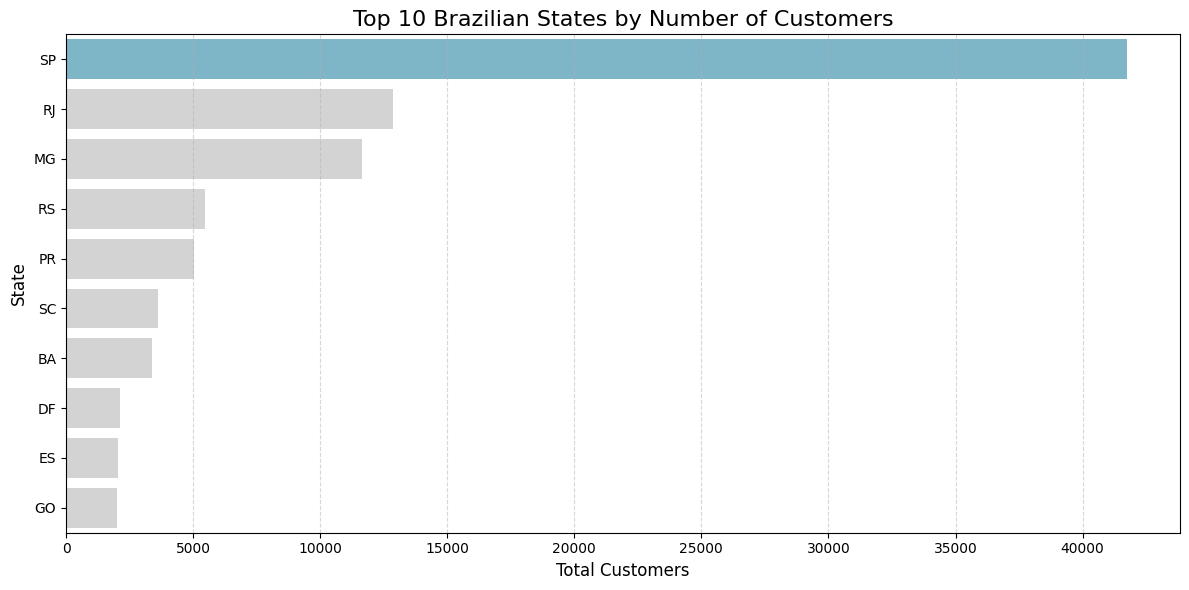

In [261]:
plt.figure(figsize=(12, 6))
colors = ["#72BCD4"] + ["#D3D3D3"] * 9

sn.barplot(
    x="customer_count",
    y="customer_state",
    data=top_10_states,
    palette=colors,
    hue="customer_state",
    legend=False
)

plt.title("Top 10 Brazilian States by Number of Customers", loc="center", fontsize=16)
plt.xlabel("Total Customers", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Selanjutnya, Menyiapkan data frekuensi (dari transaction_patterns di EDA), dengan mengambil pelanggan yang belanja 1x - 3x karena angka selebihnya sangat kecil

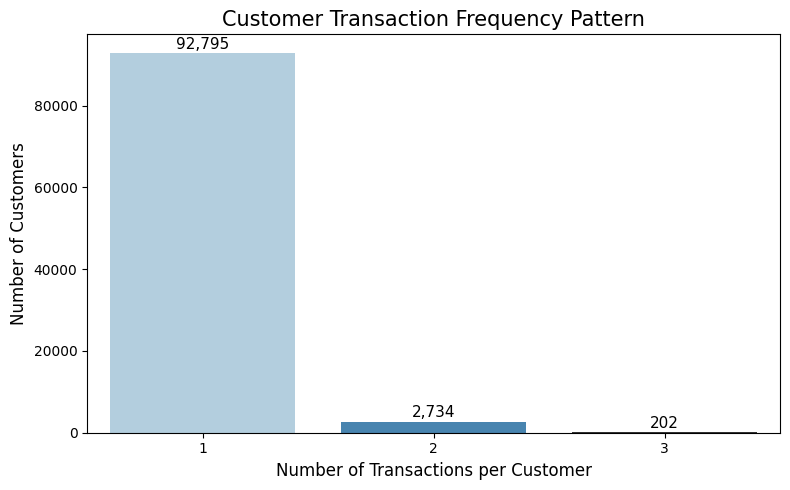

In [262]:
freq_plot_df = transaction_patterns.head(3)

plt.figure(figsize=(8, 5))

# 3. Membuat Bar Chart
sn.barplot(
    x="Frequency_of_Purchase",
    y="Total_Customers",
    data=freq_plot_df,
    palette="Blues_d",
    hue="Frequency_of_Purchase",
    legend=False
)

# 4. Menambahkan label angka di atas bar
for index, row in freq_plot_df.iterrows():
    plt.text(index, row.Total_Customers + 1000, f"{row.Total_Customers:,}", ha='center', fontsize=11)

plt.title("Customer Transaction Frequency Pattern", loc="center", fontsize=15)
plt.xlabel("Number of Transactions per Customer", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

**Insight:**
- Negara bagian SP (São Paulo) memiliki konsentrasi pelanggan yang sangat dominan dengan jumlah mencapai lebih dari 40.000 pelanggan. Angka ini jauh mengungguli wilayah besar lainnya seperti RJ (Rio de Janeiro) dan MG (Minas Gerais). Yang menunjukkan bahwa infrastruktur logistik dan strategi pemasaran harus diprioritaskan di wilayah metropolitan ini.
- Dari grafik frekuensi, terlihat pola yang sangat timpang di mana mayoritas absolut pelanggan (lebih dari 90.000 orang) hanya melakukan satu kali transaksi selama periode dua tahun.
- Jumlah pelanggan yang melakukan pembelian berulang (repeat order) sangatlah kecil. Hal ini menandakan bahwa meskipun akuisisi pelanggan baru berhasil, perusahaan masih memiliki tantangan besar dalam membangun loyalitas pelanggan agar mereka kembali berbelanja di platform

### Pertanyaan 6: Bagaimana perbandingan rata-rata nilai transaksi (Average Order Value) pelanggan berdasarkan metode pembayaran yang digunakan selama periode 2017–2018?

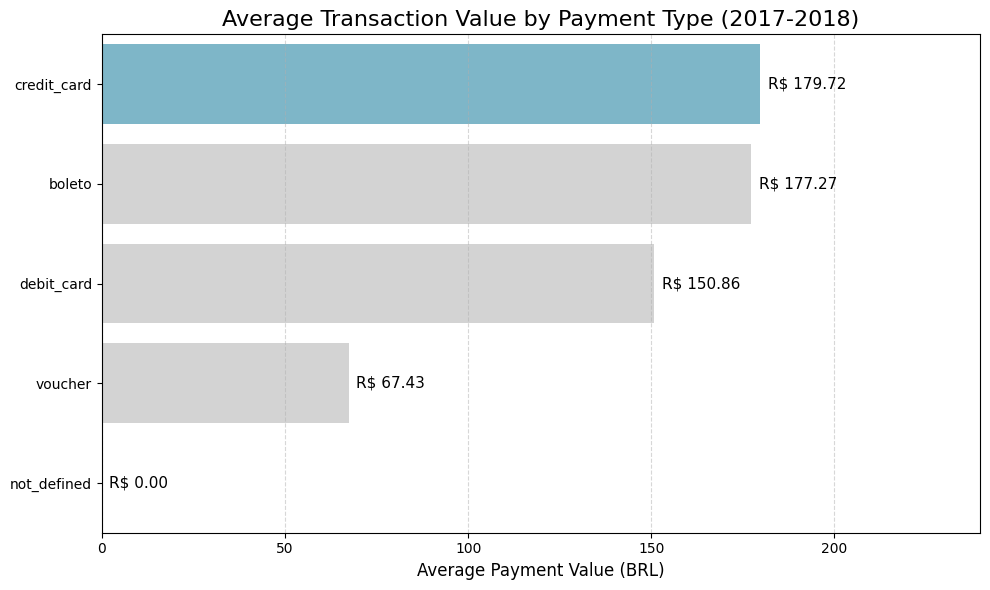

In [263]:
avg_payment_df = all_df_with_reviews.groupby(by="payment_type").payment_value.mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sn.barplot(
    x="payment_value",
    y="payment_type",
    data=avg_payment_df,
    palette=colors,
    hue="payment_type",
    legend=False
)

plt.title("Average Transaction Value by Payment Type (2017-2018)", loc="center", fontsize=16)
plt.xlabel("Average Payment Value (BRL)", fontsize=12)
plt.ylabel(None)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, avg_payment_df.payment_value.max() + 60)

for index, row in avg_payment_df.iterrows():
    plt.text(row.payment_value + 2, index, f"R$ {row.payment_value:.2f}", va='center', fontsize=11)

plt.tight_layout()
plt.show()

**Insight:**
Perbandingan rata-rata nilai transaksi menunjukkan perilaku keuangan pelanggan yang berbeda-beda tergantung metode pembayarannya:
* Metode Credit Card memiliki rata-rata nilai transaksi tertinggi, yaitu sekitar 179.72. Hal ini sangat masuk akal karena kartu kredit adalah satu-satunya metode yang mendukung fasilitas cicilan hingga 24 kali, sehingga sering digunakan untuk membeli barang-barang mahal.
* Metode Boleto menempati posisi kedua dengan rata-rata 177.27. Ini menunjukkan bahwa metode pembayaran tunai melalui bank tetap menjadi pilihan utama untuk transaksi bernilai besar di Brazil selain kartu kredit.
* Penggunaan Voucher memiliki rata-rata terendah  (67.43). Ini mengindikasikan bahwa voucher biasanya hanya digunakan sebagai potongan harga tambahan atau untuk pembelian barang dengan nominal kecil.

## Analisis Lanjutan (Opsional)

---



###Geospatial Analysis


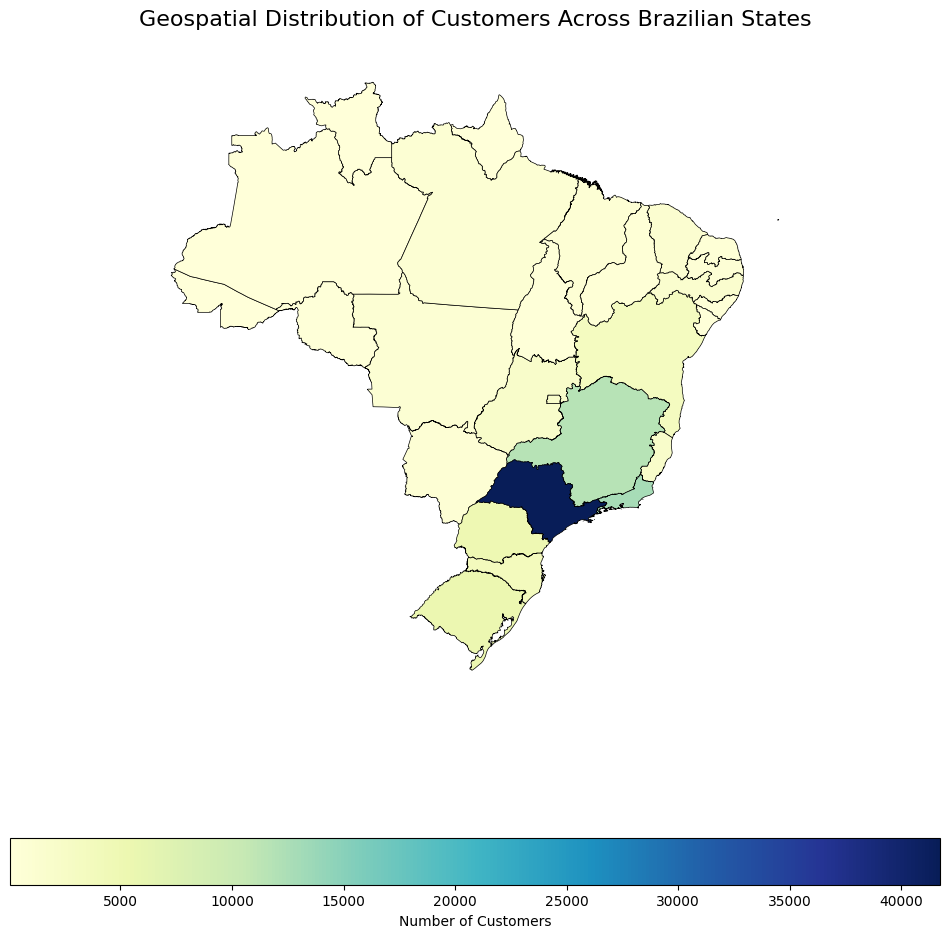

In [264]:
state_customer_df = all_df_with_reviews.groupby("customer_state").customer_id.nunique().reset_index()
state_customer_df.columns = ['state', 'customer_count']

brazil_geo_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil_map = gpd.read_file(brazil_geo_url)

brazil_map = brazil_map.merge(state_customer_df, left_on="sigla", right_on="state", how="left")

fig, ax = plt.subplots(figsize=(12, 12))
brazil_map.plot(
    column="customer_count",
    cmap="YlGnBu",
    legend=True,
    legend_kwds={'label': "Number of Customers", 'orientation': "horizontal"},
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

ax.axis('off')
plt.title("Geospatial Distribution of Customers Across Brazilian States", fontsize=16, pad=20)
plt.show()

**Insight:**

- Wilayah São Paulo (SP) mendominasi secara absolut dibandingkan negara bagian lainnya. Warna yang paling pekat terkonsentrasi di wilayah Tenggara Brasil.

- Sebaran pelanggan mengikuti kepadatan penduduk dan kemajuan ekonomi Brasil, di mana wilayah Tenggara dan Selatan memiliki basis pelanggan e-commerce yang jauh lebih matang.

- Wilayah Utara (seperti Amazonas/AM) dan Tengah menunjukkan aktivitas yang rendah.

### RFM Analysis

Pada tahap ini, saya akan melakukan analisis RFM (Recency, Frequency, & Monetary) untuk memahami perilaku pelanggan secara lebih mendalam.
- **Recency**: Seberapa baru pelanggan melakukan transaksi terakhir (dalam hari).
- **Frequency**: Seberapa sering pelanggan melakukan transaksi.
- **Monetary**: Total nilai transaksi yang dihasilkan oleh pelanggan.

In [265]:
recent_date = all_df_with_reviews['order_purchase_timestamp'].max() + pd.DateOffset(days=1)

rfm_df = all_df_with_reviews.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum"
})

rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

rfm_df['customer_id_short'] = rfm_df['customer_id'].str[:5]
rfm_df.head()

,customer_id,recency,frequency,monetary,customer_id_short
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,00003
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,0000b
2,0000f46a3911fa3c0805444483337064,586,1,86.22,0000f
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,0000f
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,0004a


Untuk mempermudah identifikasi pelanggan terbaik, selanjutnya berikut adalah visualisai Top 5 pelanggan untuk masing-masing parameter RFM. Sesuai prinsip *Explanatory Analysis*.

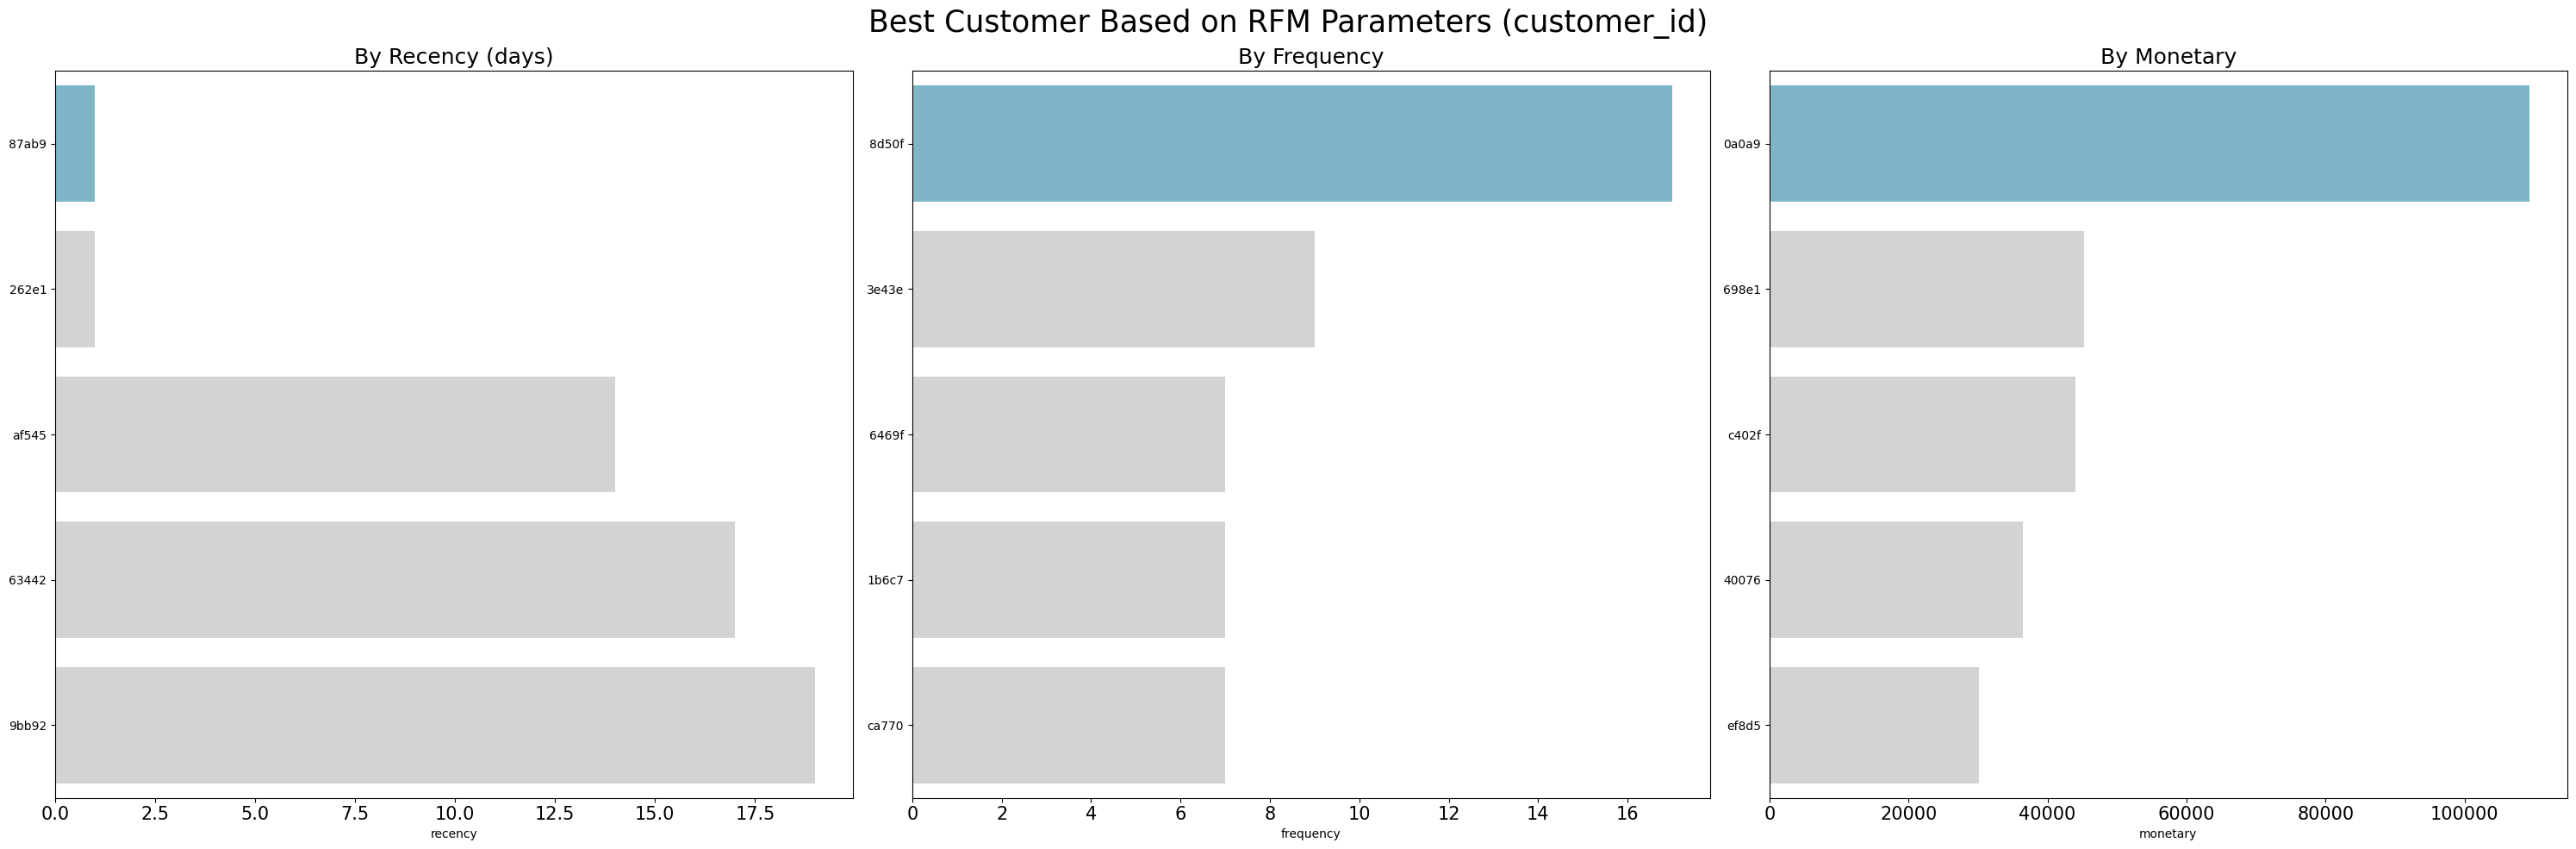

In [266]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

top_recency = rfm_df.sort_values(by="recency", ascending=True).head(5)
colors_rec = ["#72BCD4"] + ["#D3D3D3"] * (top_recency["customer_id_short"].nunique() - 1)

sn.barplot(
    y="customer_id_short", x="recency", data=top_recency,
    palette=colors_rec, hue="customer_id_short", legend=False, ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15)

top_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5)
colors_freq = ["#72BCD4"] + ["#D3D3D3"] * (top_frequency["customer_id_short"].nunique() - 1)

sn.barplot(
    y="customer_id_short", x="frequency", data=top_frequency,
    palette=colors_freq, hue="customer_id_short", legend=False, ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15)

top_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5)
colors_mon = ["#72BCD4"] + ["#D3D3D3"] * (top_monetary["customer_id_short"].nunique() - 1)

sn.barplot(
    y="customer_id_short", x="monetary", data=top_monetary,
    palette=colors_mon, hue="customer_id_short", legend=False, ax=ax[2]
)
ax[2].set_ylabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15)

plt.suptitle("Best Customer Based on RFM Parameters (customer_id)", fontsize=25)
plt.tight_layout()
plt.show()

**Insight:**
- Grafik Monetary menunjukkan pelanggan dengan ID 0a0a9 memberikan kontribusi nilai transaksi yang sangat ekstrem, mencapai lebih dari 100.000 atau hampir 2,5 kali lipat dari peringkat kedua.

- Terjadi ketimpangan antara frekuensi dan nilai belanja, di mana pelanggan paling setia (8d50f pada grafik Frequency) tidak muncul sebagai pemberi pendapatan terbesar. Hal ini mengindikasikan bahwa pelanggan yang paling konsisten memmbeli cenderung membeli produk murah, sehingga diperlukan strategi upselling atau paket bundling untuk meningkatkan nilai rata-rata transaksi mereka tanpa mengurangi loyalitas.

- Grafik Recency memperlihatkan adanya kesenjangan aktivitas, di mana tiga pelanggan di posisi bawah (af545, 63442, 9bb92) sudah tidak bertransaksi selama 14 hingga 19 hari dibandingkan pelanggan teratas yang masih aktif dalam 2 hari terakhir. Kelompok ini berada dalam zona risiko tinggi untuk beralih ke kompetitor, sehingga diperlukan intervensi segera melalui kampanye win-back atau promo khusus untuk memicu mereka kembali bertransaksi.

## Conclusion

- **Pertanyaan 1: Bagaimana tren pertumbuhan penjualan dan total revenue perusahaan dalam periode tahun 2017 hingga 2018?**
Berdasarkan analisis tren bulanan, performa perusahaan menunjukkan pertumbuhan yang sangat positif. Lonjakan transaksi dan pendapatan paling signifikan terjadi pada bulan November 2017 (bertepatan dengan momen Black Friday). Meskipun terjadi fluktuasi di awal tahun, volume transaksi pada tahun 2018 secara konsisten tetap berada pada level yang jauh lebih tinggi dibandingkan rata-rata tahun 2017, menandakan pertumbuhan pasar yang sehat.

- **Pertanyaan 2: Kategori produk apa yang memiliki volume penjualan tertinggi serta kategori mana yang menghasilkan revenue terbesar selama periode 2017-2018?**
Kategori produk bed_bath_table (cama_mesa_banho) merupakan penggerak utama bisnis karena mendominasi baik dari sisi volume penjualan maupun total pendapatan (revenue). Kategori lain yang juga menunjukkan performa kuat adalah health_beauty dan sports_leisure. Perusahaan perlu menjaga kualitas layanan dan stok pada kategori-kategori ini karena perannya yang krusial terhadap total pendapatan tahunan.

- **Pertanyaan 3: Bagaimana performa ketepatan waktu pengiriman barang dibandingkan dengan estimasi yang diberikan kepada pelanggan?**
Sistem logistik perusahaan bekerja dengan sangat baik, di mana mayoritas pesanan (89.672 transaksi) berhasil sampai tepat waktu atau bahkan lebih cepat dari estimasi awal. Hal ini menunjukkan bahwa penentuan estimasi waktu oleh tim operasional sudah cukup realistis. Namun, tetap ditemukan 6.532 transaksi yang mengalami keterlambatan, yang menjadi area utama untuk perbaikan layanan.

- **Pertanyaan 4: Bagaimana keterlambatan pengiriman memengaruhi distribusi skor ulasan pelanggan dan seberapa besar penurunan rating yang terjadi pada tahun 2017-2018?**
Keterlambatan pengiriman terbukti menjadi faktor tunggal terbesar yang merusak kepuasan pelanggan secara drastis. Pesanan yang sampai tepat waktu memiliki rata-rata skor ulasan yang tinggi (4.13) , sedangkan pesanan yang terlambat mengalami penurunan skor yang tajam hingga mencapai rata-rata 2.25. Menekan angka keterlambatan merupakan strategi paling efektif untuk meningkatkan reputasi dan rating platform secara keseluruhan.

- **Pertanyaan 5: Negara bagian mana yang memiliki konsentrasi pelanggan terbanyak serta bagaimana pola frekuensi transaksi pelanggan selama tahun 2018?**
Konsentrasi pasar utama perusahaan berada di wilayah Tenggara Brasil, dengan negara bagian São Paulo (SP) sebagai wilayah dengan jumlah pelanggan dan pesanan paling dominan. Terkait pola perilaku, mayoritas pelanggan hanya melakukan satu kali transaksi selama periode dua tahun. Rendahnya angka pembelian berulang (repeat order) mengindikasikan bahwa perusahaan perlu merancang strategi retention yang lebih kuat agar pelanggan tidak hanya datang sekali saja.

- **Pertanyaan 6: Bagaimana perbandingan rata-rata nilai transaksi (Average Order Value) pelanggan berdasarkan metode pembayaran yang digunakan selama periode 2017-2018?**
Metode pembayaran credit_card memiliki rata-rata nilai transaksi (Average Order Value) tertinggi dibandingkan metode lainnya, yaitu sekitar R$ 179.72. Hal ini berkaitan erat dengan fasilitas cicilan hingga 24 kali yang memicu pelanggan untuk melakukan pembelian barang-barang bernilai besar. Sebaliknya, penggunaan voucher cenderung digunakan untuk transaksi dengan nominal yang paling rendah